# Predicting House Prices with Linear Regression
**Oasis Infobyte Internship · Data Analytics · Level 2 — Task 1**<br>
**Author:** Ojewumi Asaph Felix

**Objective:** build and evaluate a linear regression model that predicts the sale price of a house from its characteristics (size, quality, location, age, rooms…), and understand which features drive the price.

**Dataset:** *House Prices — Advanced Regression Techniques* (Kaggle competition, Ames Housing data by Dean De Cock), from OpenML (dataset 42165) — **1,460 houses sold in Ames, Iowa (2006–2010), 79 features**, prices in US dollars.

> **Key results**
> - A **Linear Regression on 14 well-chosen features** explains **91 % of the price variance** on unseen houses (R² = 0.91, RMSE ≈ \$22,400).
> - **Overall quality, living area and location (neighbourhood)** are the strongest price drivers.
> - Bonus: a **Lasso** model using all 79 features reaches **R² = 0.93** (RMSE ≈ \$19,500).

**Contents**
1. Data loading and exploration
2. Missing values
3. Feature selection
4. Correlation analysis
5. Preparation: outliers, encoding, train/test split
6. Linear Regression
7. Evaluation: MSE, RMSE, R², actual vs. predicted, residuals
8. Coefficient analysis
9. Bonus: Ridge and Lasso
10. Conclusion

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Categories that appear only in the test set are encoded as all zeros: expected, so the warning is hidden
warnings.filterwarnings("ignore", message="Found unknown categories")
pd.set_option("display.max_columns", 90)
pd.set_option("display.float_format", "{:,.3f}".format)

BLUE, ORANGE, GREY, INK, MUTED = "#2a78d6", "#eb6834", "#b9b8b3", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfcecb", "axes.labelcolor": MUTED, "axes.titleweight": "bold",
    "axes.titlesize": 12.5, "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titlepad": 12,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe8", "grid.linewidth": 0.8, "axes.axisbelow": True,
})
dollars = mtick.FuncFormatter(lambda x, _: f"{'-' if x < 0 else ''}${abs(x) / 1e3:,.0f}k")

## 1. Data Loading and Exploration

In [2]:
df = pd.read_csv("data/house_prices.csv")
print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Numerical columns  :", df.select_dtypes("number").shape[1] - 1, "(without Id)")
print("Categorical columns:", df.select_dtypes(exclude="number").shape[1])
print("Duplicated rows    :", df.duplicated().sum())
df["SalePrice"].describe()

Numerical columns  : 37 (without Id)
Categorical columns: 43
Duplicated rows    : 0


count     1,460.000
mean    180,921.196
std      79,442.503
min      34,900.000
25%     129,975.000
50%     163,000.000
75%     214,000.000
max     755,000.000
Name: SalePrice, dtype: float64

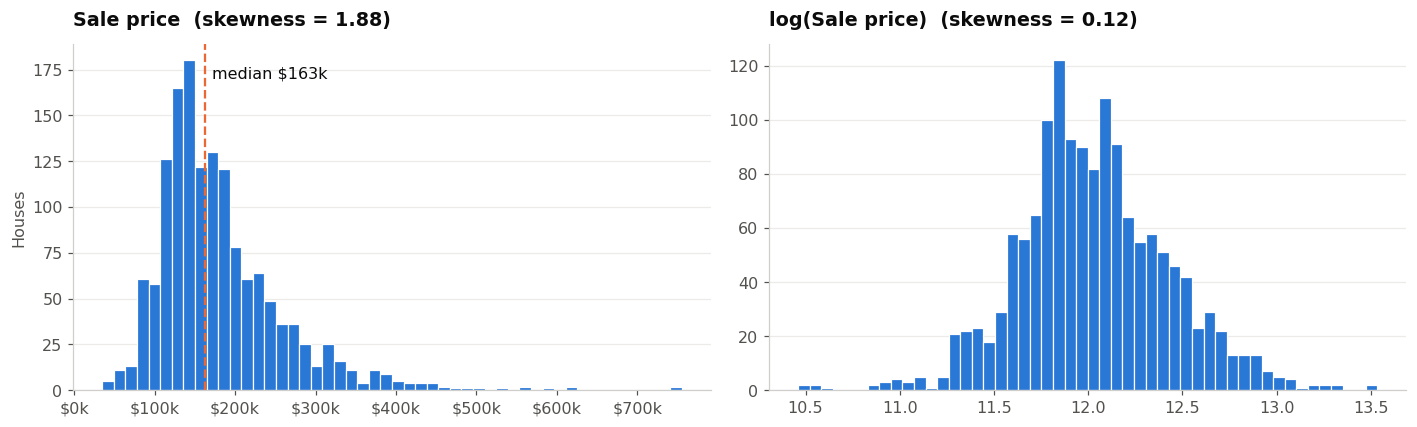

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["SalePrice"], bins=50, color=BLUE, edgecolor="white", linewidth=0.8)
axes[0].axvline(df["SalePrice"].median(), color=ORANGE, lw=1.5, ls="--")
axes[0].text(df["SalePrice"].median() * 1.05, axes[0].get_ylim()[1] * 0.9, f"median ${df['SalePrice'].median() / 1e3:,.0f}k", color=INK)
axes[0].xaxis.set_major_formatter(dollars)
axes[0].set_title(f"Sale price  (skewness = {df['SalePrice'].skew():.2f})")
axes[0].set_ylabel("Houses")
axes[0].grid(axis="x", visible=False)

axes[1].hist(np.log(df["SalePrice"]), bins=50, color=BLUE, edgecolor="white", linewidth=0.8)
axes[1].set_title(f"log(Sale price)  (skewness = {np.log(df['SalePrice']).skew():.2f})")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("images/price_distribution.png")
plt.show()

**Observations:**
- Prices range from **\$34,900 to \$755,000**, with a median of **\$163,000**. No duplicated rows.
- The distribution is **right-skewed** (skewness 1.88): a few expensive houses stretch the right tail.
- After a **log transformation**, the distribution is almost symmetric (skewness 0.12). Linear regression works better when errors are symmetric and proportional to the price, so we will **predict log(price)** and convert the predictions back to dollars for evaluation.

## 2. Missing Values

In [5]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
pd.DataFrame({"missing": na, "% of rows": na / len(df) * 100})

,missing,% of rows
PoolQC,1453,99.521
MiscFeature,1406,96.301
Alley,1369,93.767
Fence,1179,80.753
MasVnrType,872,59.726
FireplaceQu,690,47.260
LotFrontage,259,17.740
GarageType,81,5.548
GarageYrBlt,81,5.548
GarageFinish,81,5.548


**Most of these values are not really missing.** According to the dataset documentation, an empty `PoolQC` means **"no pool"**, an empty `GarageType` means **"no garage"**, an empty `Alley` means **"no alley access"**, etc. Filling them with the most frequent value would invent pools and garages that do not exist.

| Columns | Strategy | Justification |
|---|---|---|
| `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `Garage*` (type, finish, quality, condition), `Bsmt*` (quality, condition, exposure, finish), `MasVnrType` | **"None"** | Empty = the house has no pool / garage / basement / fireplace… |
| `MasVnrArea` | **0** | No masonry veneer → area of 0 |
| `GarageYrBlt` | **YearBuilt** | Houses without garage: use the construction year to keep the column numeric |
| `LotFrontage` (18 %) | **Median of the neighbourhood** | Street frontage depends on the neighbourhood's lot layout |
| `Electrical` (1 row) | **Mode** | A real missing value, only one row |

In [6]:
NONE_COLS = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType", "GarageFinish",
             "GarageQual", "GarageCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
             "BsmtFinType2", "MasVnrType"]
df[NONE_COLS] = df[NONE_COLS].fillna("None")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])
print("Missing values left:", df.isna().sum().sum())

Missing values left: 0


## 3. Feature Selection
The task mentions **area, location, number of rooms and age**. We create three more meaningful features and choose predictors that a buyer or real-estate agent would look at:

| Group | Features | Why they should matter |
|---|---|---|
| **Quality** | `OverallQual`, `OverallCond`, `KitchenQual` | Materials and finish are what buyers pay for |
| **Size** | `GrLivArea` (living area), `TotalBsmtSF` (basement), `LotArea` | More square feet → higher price |
| **Rooms & equipment** | `TotalBath` *(new)*, `BedroomAbvGr`, `GarageCars`, `Fireplaces`, `CentralAir` | Comfort and practicality |
| **Age** | `HouseAge` *(new)*, `YearsSinceRemod` *(new)* | Older, non-renovated houses sell for less |
| **Location** | `Neighborhood` (25 areas) | "Location, location, location" |

We avoid putting **redundant features** together (e.g. `GarageArea` with `GarageCars`, or `1stFlrSF` with `TotalBsmtSF`): they measure the same thing, which makes coefficients unstable and hard to interpret (multicollinearity).

In [7]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["YearsSinceRemod"] = df["YrSold"] - df["YearRemodAdd"]
df["TotalBath"] = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]

NUM_FEATURES = ["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars", "TotalBath", "HouseAge",
                "YearsSinceRemod", "LotArea", "Fireplaces", "OverallCond", "BedroomAbvGr"]
CAT_FEATURES = ["Neighborhood", "KitchenQual", "CentralAir"]
print(len(NUM_FEATURES) + len(CAT_FEATURES), "features selected")

14 features selected


## 4. Correlation Analysis

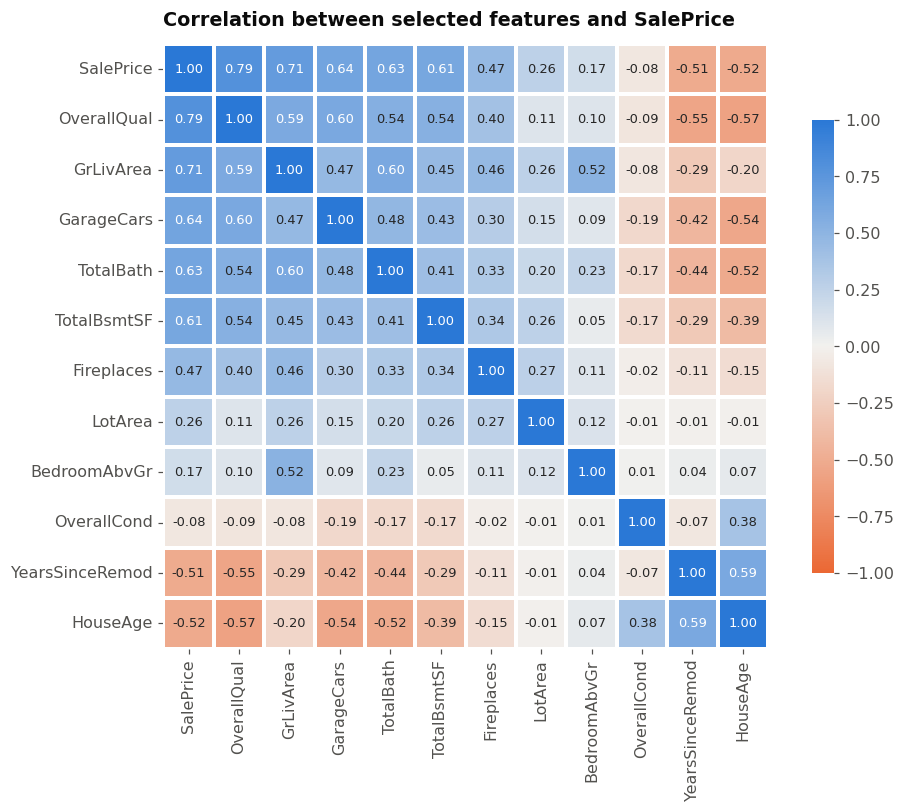

In [8]:
corr = df[NUM_FEATURES + ["SalePrice"]].corr()
order = corr["SalePrice"].sort_values(ascending=False).index
corr = corr.loc[order, order]

diverging = LinearSegmentedColormap.from_list("div", [ORANGE, "#f2f1ee", BLUE])
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=diverging, vmin=-1, vmax=1, center=0, square=True,
            linewidths=1.5, linecolor="white", cbar_kws={"shrink": 0.75}, annot_kws={"fontsize": 8.5}, ax=ax)
ax.set_title("Correlation between selected features and SalePrice")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()

**Observations:**
- The features most correlated with price are **OverallQual (0.79)**, **GrLivArea (0.71)**, **GarageCars (0.64)**, **TotalBsmtSF (0.61)** and **TotalBath (0.63)**.
- **HouseAge (−0.52)** and **YearsSinceRemod (−0.51)** are negatively correlated: older and non-renovated houses are cheaper.
- `OverallCond` is almost not correlated with price (−0.08) on its own; the model will show whether it still helps once quality and age are known.

## 5. Preparation
### 5.1 Outliers
The author of the dataset recommends removing houses **larger than 4,000 sq ft** that were sold at an abnormally **low price** (partial sales). They are clearly visible on the chart below.

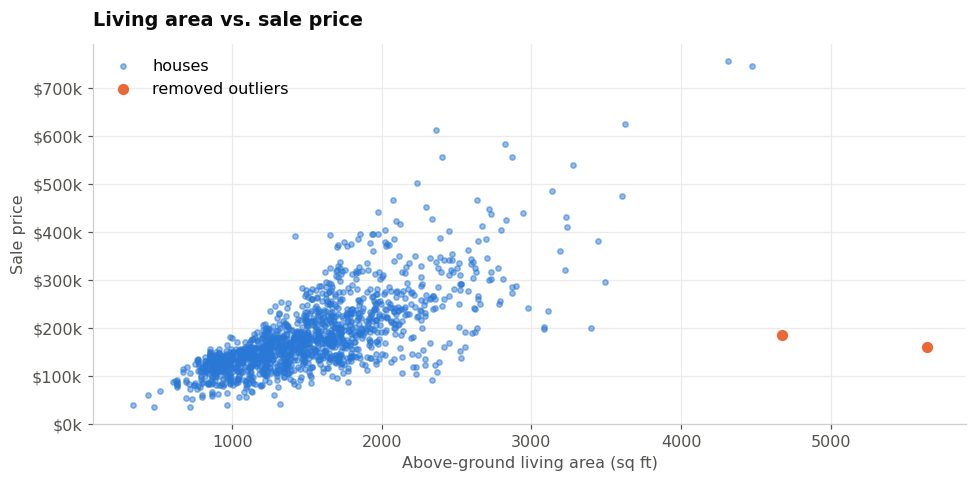

Houses removed: 2 → remaining: 1458


In [9]:
outliers = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(df.loc[~outliers, "GrLivArea"], df.loc[~outliers, "SalePrice"], s=12, alpha=0.5, color=BLUE, label="houses")
ax.scatter(df.loc[outliers, "GrLivArea"], df.loc[outliers, "SalePrice"], s=70, color=ORANGE, label="removed outliers",
           edgecolors="white", linewidths=1)
ax.yaxis.set_major_formatter(dollars)
ax.set_xlabel("Above-ground living area (sq ft)")
ax.set_ylabel("Sale price")
ax.set_title("Living area vs. sale price")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.savefig("images/outliers.png")
plt.show()

df = df[~outliers].reset_index(drop=True)
print("Houses removed:", outliers.sum(), "→ remaining:", len(df))

### 5.2 Encoding and train / test split (80 / 20)
- **Categorical features → One-Hot Encoding** (one 0/1 column per category, the first one dropped to avoid redundancy).
- **Numerical features → standardised** (mean 0, std 1), so that the coefficients can be compared with each other.
- Both steps are placed in a **pipeline** fitted on the training set only.

In [10]:
X = df[NUM_FEATURES + CAT_FEATURES]
y = np.log(df["SalePrice"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
])
print(f"Training set: {len(X_train)} houses · Test set: {len(X_test)} houses")

Training set: 1166 houses · Test set: 292 houses


## 6. Linear Regression

In [11]:
model = Pipeline([("prep", preprocess), ("reg", LinearRegression())])
model.fit(X_train, y_train)

pred_price = np.exp(model.predict(X_test))      # back from log to dollars
true_price = np.exp(y_test)
print("Number of model inputs after encoding:", model.named_steps["reg"].coef_.shape[0])

Number of model inputs after encoding: 39


## 7. Evaluation

In [12]:
def evaluate(true, pred):
    mse = mean_squared_error(true, pred)
    return {"MSE": mse, "RMSE ($)": np.sqrt(mse), "MAE ($)": mean_absolute_error(true, pred), "R²": r2_score(true, pred)}

train_pred = np.exp(model.predict(X_train))
scores = pd.DataFrame({"Train": evaluate(np.exp(y_train), train_pred), "Test": evaluate(true_price, pred_price)}).T
scores.style.format({"MSE": "{:,.0f}", "RMSE ($)": "${:,.0f}", "MAE ($)": "${:,.0f}", "R²": "{:.3f}"})

,MSE,RMSE ($),MAE ($),R²
Train,"479,780,067","$21,904","$14,670",0.926
Test,"501,260,884","$22,389","$16,083",0.909


**Interpretation:**
- **R² = 0.91 on the test set**: the model explains 91 % of the variation in prices of houses it has never seen.
- **RMSE ≈ \$22,400** and **MAE ≈ \$16,100**: on average the prediction is about \$16k away from the real price, i.e. **around 10 % of the median price**. RMSE is higher than MAE because it penalises large errors more.
- Train and test scores are close: the model **does not overfit**.

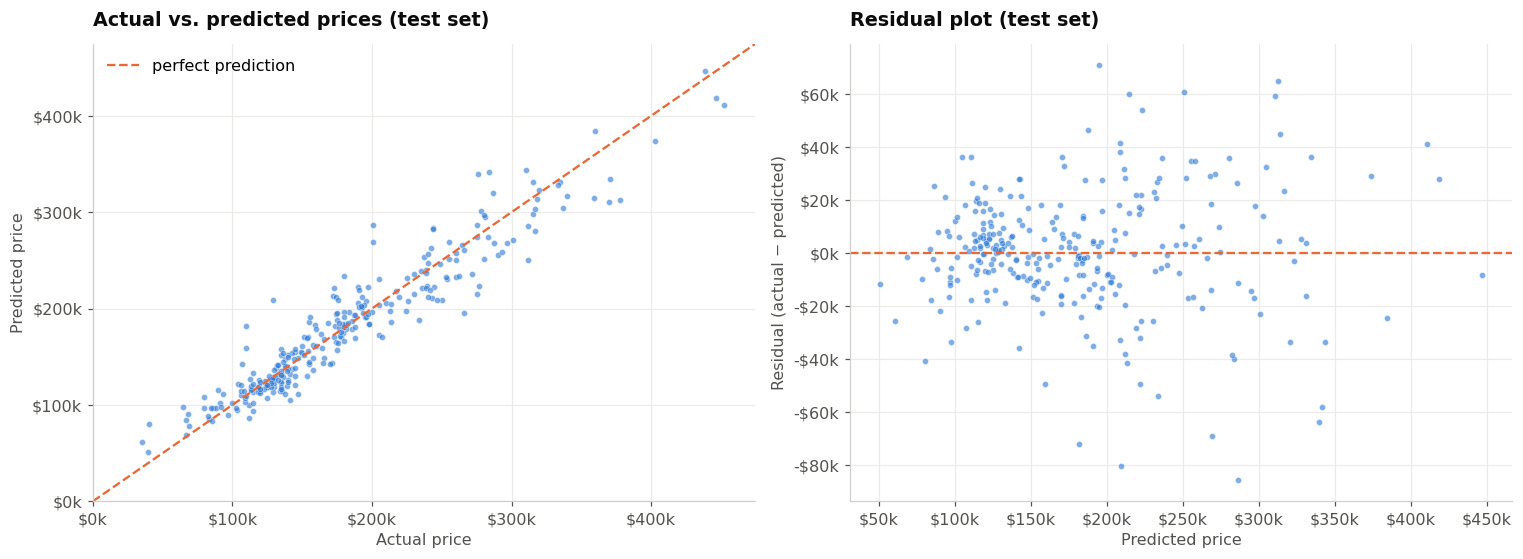

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
lim = [0, max(true_price.max(), pred_price.max()) * 1.05]
axes[0].scatter(true_price, pred_price, s=16, alpha=0.6, color=BLUE, edgecolors="white", linewidths=0.4)
axes[0].plot(lim, lim, color=ORANGE, lw=1.5, ls="--", label="perfect prediction")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].xaxis.set_major_formatter(dollars); axes[0].yaxis.set_major_formatter(dollars)
axes[0].set_xlabel("Actual price"); axes[0].set_ylabel("Predicted price")
axes[0].set_title("Actual vs. predicted prices (test set)")
axes[0].legend(frameon=False, loc="upper left")

residuals = true_price - pred_price
axes[1].scatter(pred_price, residuals, s=16, alpha=0.6, color=BLUE, edgecolors="white", linewidths=0.4)
axes[1].axhline(0, color=ORANGE, lw=1.5, ls="--")
axes[1].xaxis.set_major_formatter(dollars); axes[1].yaxis.set_major_formatter(dollars)
axes[1].set_xlabel("Predicted price"); axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residual plot (test set)")
plt.tight_layout()
plt.savefig("images/actual_vs_predicted.png")
plt.show()

**Observations:**
- The points follow the **diagonal line** closely: predictions are good across the whole price range.
- The residuals are **centred on 0 with no clear pattern** (no curve, no trend). The spread grows slightly with the price — expensive houses are harder to predict in dollars — but predicting log(price) keeps this effect small.
- A few houses between **\$350k and \$400k are under-estimated** by \$50–70k: high-end features (exceptional finish, pool, large porch…) are not all in our 14 features.

## 8. Coefficient Analysis
Because the target is **log(price)**, a coefficient can be read as a **percentage effect on the price**:
- for numerical features (standardised): effect of **+1 standard deviation**;
- for categories: effect compared with the reference category (e.g. neighbourhood *Blmngtn*, kitchen quality *Excellent*).

In [14]:
names = model.named_steps["prep"].get_feature_names_out()
names = [n.split("__", 1)[1] for n in names]
effect = pd.Series((np.exp(model.named_steps["reg"].coef_) - 1) * 100, index=names)

num_effect = effect[NUM_FEATURES].sort_values()
std = X_train[NUM_FEATURES].std()
summary = pd.DataFrame({"effect of +1 std (%)": num_effect,
                        "1 std =": [f"{std[f]:,.1f}" for f in num_effect.index]})
summary.sort_values("effect of +1 std (%)", ascending=False)

,effect of +1 std (%),1 std =
GrLivArea,13.265,504.8
OverallQual,7.454,1.4
TotalBsmtSF,6.133,414.4
OverallCond,5.368,1.1
GarageCars,4.536,0.7
TotalBath,4.173,0.8
Fireplaces,2.651,0.6
LotArea,2.285,"10,637.2"
BedroomAbvGr,-1.068,0.8
YearsSinceRemod,-1.239,20.6


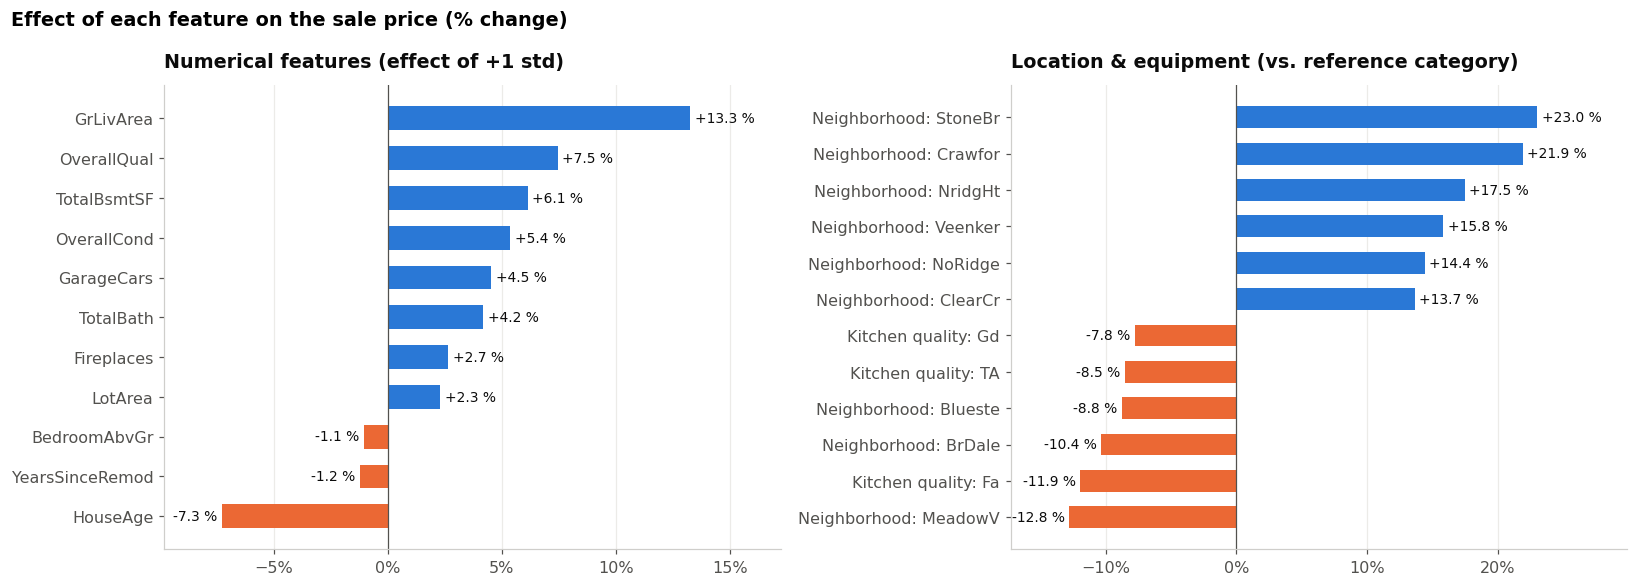

In [15]:
cat_effect = effect.drop(NUM_FEATURES).sort_values()
cat_top = pd.concat([cat_effect.head(6), cat_effect.tail(6)])
cat_top.index = [i.replace("Neighborhood_", "Neighborhood: ").replace("KitchenQual_", "Kitchen quality: ")
                 .replace("CentralAir_Y", "Central air: yes") for i in cat_top.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
for ax, data, title in [(axes[0], num_effect, "Numerical features (effect of +1 std)"),
                        (axes[1], cat_top, "Location & equipment (vs. reference category)")]:
    bars = ax.barh(data.index, data.values, color=[BLUE if v > 0 else ORANGE for v in data.values], height=0.6)
    ax.bar_label(bars, labels=[f"{v:+.1f} %" for v in data.values], padding=3, color=INK, fontsize=9)
    ax.axvline(0, color=MUTED, lw=0.8)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))
    ax.set_xlim(min(data.min() * 1.35, -3), data.max() * 1.3)
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
plt.suptitle("Effect of each feature on the sale price (% change)", fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
plt.savefig("images/coefficients.png")
plt.show()

**Observations:**
- **Biggest positive drivers:** **living area** (**+13 %** for +505 sq ft) and **overall quality** (**+7.5 %** for +1.4 points on the 1–10 scale), then **basement size** (+6 %) and **condition** (+5 %). **Age** works the other way: **−7 %** for 30 more years.
- **Location matters a lot:** at equal size and quality, a house in *StoneBr* (+23 %), *Crawfor* (+22 %) or *NridgHt* (+18 %) sells for much more than in the reference neighbourhood (*Blmngtn*), while *MeadowV* (−13 %) and *BrDale* (−10 %) are cheaper.
- **Equipment:** a kitchen of **fair** quality costs **−12 %** compared with an excellent one (−8.5 % for "typical"), and **central air conditioning** adds **+9 %**.
- **BedroomAbvGr** has a small **negative** effect: at the same living area, more bedrooms means smaller rooms — buyers pay for space, not for the number of walls.
- `OverallCond` has a **positive** effect once quality and age are taken into account, although its simple correlation with price was almost zero.

## 9. Bonus: Ridge and Lasso Regularisation
Ridge and Lasso add a **penalty on large coefficients**, which reduces overfitting when there are many features. We compare, on the same train/test split:
- our Linear Regression with 14 selected features;
- a Linear Regression, a Ridge and a Lasso using **all 79 features** (≈ 300 columns after encoding). The penalty strength is chosen by cross-validation.

In [16]:
ALL_NUM = [c for c in df.select_dtypes("number").columns if c not in ["Id", "SalePrice"]]
ALL_CAT = list(df.select_dtypes(exclude="number").columns)
Xa_train, Xa_test = df.loc[X_train.index, ALL_NUM + ALL_CAT], df.loc[X_test.index, ALL_NUM + ALL_CAT]

def full_pipeline(reg, drop):
    prep = ColumnTransformer([("num", StandardScaler(), ALL_NUM),
                              ("cat", OneHotEncoder(drop=drop, handle_unknown="ignore", sparse_output=False), ALL_CAT)])
    return Pipeline([("prep", prep), ("reg", reg)]).fit(Xa_train, y_train)

candidates = {
    "Linear Regression (14 features)": (model, X_test),
    "Linear Regression (all features)": (full_pipeline(LinearRegression(), "first"), Xa_test),
    "Ridge (all features)": (full_pipeline(RidgeCV(alphas=np.logspace(-1, 3, 30)), None), Xa_test),
    "Lasso (all features)": (full_pipeline(LassoCV(cv=5, random_state=0, max_iter=20000), None), Xa_test),
}
comparison = pd.DataFrame({name: evaluate(true_price, np.exp(m.predict(Xt))) for name, (m, Xt) in candidates.items()}).T
lasso = candidates["Lasso (all features)"][0].named_steps["reg"]
print(f"Lasso kept {np.sum(lasso.coef_ != 0)} of {lasso.coef_.size} columns (the others were set to exactly 0)")
comparison.style.format({"MSE": "{:,.0f}", "RMSE ($)": "${:,.0f}", "MAE ($)": "${:,.0f}", "R²": "{:.3f}"})

Lasso kept 124 of 301 columns (the others were set to exactly 0)


,MSE,RMSE ($),MAE ($),R²
Linear Regression (14 features),"501,260,884","$22,389","$16,083",0.909
Linear Regression (all features),"479,871,386","$21,906","$15,554",0.913
Ridge (all features),"401,590,078","$20,040","$14,600",0.927
Lasso (all features),"381,904,931","$19,542","$14,166",0.931


**Observations:**
- With **all features**, plain Linear Regression gains little (R² 0.913), because hundreds of columns add noise.
- **Ridge (R² 0.927) and Lasso (R² 0.931)** do better: the penalty keeps the useful information and neutralises the noise. **Lasso** also performs automatic **feature selection** by setting most coefficients exactly to zero.
- Our simple 14-feature model stays very competitive (R² 0.909) while being **much easier to explain** to a client.

## 10. Conclusion
- A **Linear Regression on 14 features** predicts the price of unseen houses with **R² = 0.91** and a typical error of **≈ \$16,000 (≈ 10 % of the median price)**.
- The price is mainly driven by **quality, living area, location and age**. Buyers pay for **space and finish**, not for the number of bedrooms.
- For maximum accuracy, a **Lasso** model on all features reaches **R² = 0.93**; for explaining prices to clients, the 14-feature model is the best compromise.

**Business use:** a real-estate agency could use the model to **suggest a listing price**, detect **over- or under-priced** houses (large residuals), and show sellers which renovations (kitchen, central air) add the most value.

**Limitations:** data from one city (Ames, 2006–2010) — the model would need to be retrained for another market; luxury houses are less well predicted; linear models cannot capture complex interactions (tree-based models such as gradient boosting could go further).